In [1]:
# ── CELL 1: Import libraries ────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")
print(f"   Pandas version  : {pd.__version__}")
print(f"   NumPy version   : {np.__version__}")


✅ Libraries imported successfully
   Pandas version  : 2.3.2
   NumPy version   : 1.26.4


In [5]:
# ── CELL 2: Load dataset ────────────────────────────────────
RAW_PATH = "F:/Rithika/Projects/hr_analytics/data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"
PROCESSED_PATH = "F:/Rithika/Projects/hr_analytics/data/processed/hr_cleaned.csv"

df = pd.read_csv(RAW_PATH)

print(f"✅ Dataset loaded successfully")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print()
print("First 5 rows:")
df.head()

✅ Dataset loaded successfully
   Rows    : 1470
   Columns : 35

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# ── CELL 3: Basic info ──────────────────────────────────────
print("Dataset Info:")
print("-" * 40)
df.info()

print()
print("Column names:")
print(list(df.columns))


Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement         

In [7]:
# ── CELL 4: Check for missing values ────────────────────────
print("Missing values per column:")
print("-" * 40)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")

print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
----------------------------------------
✅ No missing values found!

Duplicate rows: 0


In [8]:
# ── CELL 5: Check unique values for key columns ─────────────
categorical_cols = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus', 'OverTime'
]

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Department: ['Sales' 'Research & Development' 'Human Resources']
EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Gender: ['Female' 'Male']
JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
MaritalStatus: ['Single' 'Married' 'Divorced']
OverTime: ['Yes' 'No']


In [9]:
# ── CELL 6: Drop constant/useless columns ───────────────────
# These columns have only 1 unique value — no analytical value
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

print(f"✅ Dropped {len(cols_to_drop)} useless columns: {cols_to_drop}")
print(f"   Remaining columns: {df.shape[1]}")


✅ Dropped 3 useless columns: ['EmployeeCount', 'Over18', 'StandardHours']
   Remaining columns: 32


In [10]:
# ── CELL 7: Encode target variable ──────────────────────────
# Attrition: Yes → 1, No → 0 (needed for SQL and Power BI calculations)
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("✅ Attrition encoded:")
print(df['Attrition_Flag'].value_counts())
print()
attrition_rate = df['Attrition_Flag'].mean() * 100
print(f"   Overall Attrition Rate: {attrition_rate:.1f}%")

✅ Attrition encoded:
Attrition_Flag
0    1233
1     237
Name: count, dtype: int64

   Overall Attrition Rate: 16.1%


In [11]:
# ── CELL 8: Create Age Band column ──────────────────────────
def age_band(age):
    if age < 25:
        return 'Under 25'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    else:
        return '45+'

df['AgeBand'] = df['Age'].apply(age_band)

print("✅ Age Band created:")
print(df['AgeBand'].value_counts())

✅ Age Band created:
AgeBand
25-34       554
35-44       505
45+         314
Under 25     97
Name: count, dtype: int64


In [12]:
# ── CELL 9: Create Salary Band column ───────────────────────
def salary_band(income):
    if income < 3000:
        return 'Under $3K'
    elif income < 5000:
        return '$3K-$5K'
    elif income < 8000:
        return '$5K-$8K'
    else:
        return 'Above $8K'

df['SalaryBand'] = df['MonthlyIncome'].apply(salary_band)

print("✅ Salary Band created:")
print(df['SalaryBand'].value_counts())


✅ Salary Band created:
SalaryBand
Under $3K    395
Above $8K    381
$3K-$5K      354
$5K-$8K      340
Name: count, dtype: int64


In [13]:
# ── CELL 10: Create Tenure Band column ──────────────────────
def tenure_band(years):
    if years <= 2:
        return '0-2 Years'
    elif years <= 5:
        return '3-5 Years'
    elif years <= 10:
        return '6-10 Years'
    else:
        return '10+ Years'

df['TenureBand'] = df['YearsAtCompany'].apply(tenure_band)

print("✅ Tenure Band created:")
print(df['TenureBand'].value_counts())


✅ Tenure Band created:
TenureBand
6-10 Years    448
3-5 Years     434
0-2 Years     342
10+ Years     246
Name: count, dtype: int64


In [14]:
# ── CELL 11: Summary statistics ─────────────────────────────
print("Summary Statistics — Numerical Columns:")
print("-" * 50)
df.describe().round(2)


Summary Statistics — Numerical Columns:
--------------------------------------------------


,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1024.87,2.72,65.89,2.73,2.06,2.73,...,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12,0.16
std,9.14,403.51,8.11,1.02,602.02,1.09,20.33,0.71,1.11,1.10,...,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57,0.37
min,18.00,102.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,...,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,491.25,2.00,48.00,2.00,1.00,2.00,...,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00,0.00
50%,36.00,802.00,7.00,3.00,1020.50,3.00,66.00,3.00,2.00,3.00,...,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00,0.00
75%,43.00,1157.00,14.00,4.00,1555.75,4.00,83.75,3.00,3.00,4.00,...,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00,0.00
max,60.00,1499.00,29.00,5.00,2068.00,4.00,100.00,4.00,5.00,4.00,...,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00,1.00


Attrition by Department:
                        Attrition_Count  Total  Attrition_Rate
Department                                                    
Sales                                92    446            20.6
Human Resources                      12     63            19.0
Research & Development              133    961            13.8


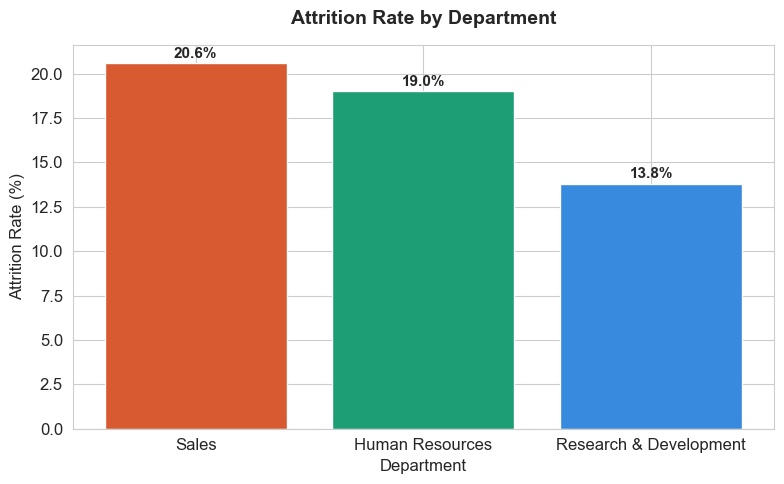

✅ Chart saved to screenshots/


In [16]:
# ── CELL 12: EDA — Attrition rate by Department ─────────────
dept_attrition = df.groupby('Department')['Attrition_Flag'].agg(['sum', 'count', 'mean'])
dept_attrition.columns = ['Attrition_Count', 'Total', 'Attrition_Rate']
dept_attrition['Attrition_Rate'] = (dept_attrition['Attrition_Rate'] * 100).round(1)
dept_attrition = dept_attrition.sort_values('Attrition_Rate', ascending=False)

print("Attrition by Department:")
print(dept_attrition)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dept_attrition.index, dept_attrition['Attrition_Rate'],
              color=['#D85A30', '#1D9E75', '#378ADD'])
ax.set_title('Attrition Rate by Department', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Department')
ax.set_ylabel('Attrition Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(r'F:\Rithika\Projects\hr_analytics\screenshots\01_attrition_by_dept.png', dpi=150)
plt.show()
print("✅ Chart saved to screenshots/")

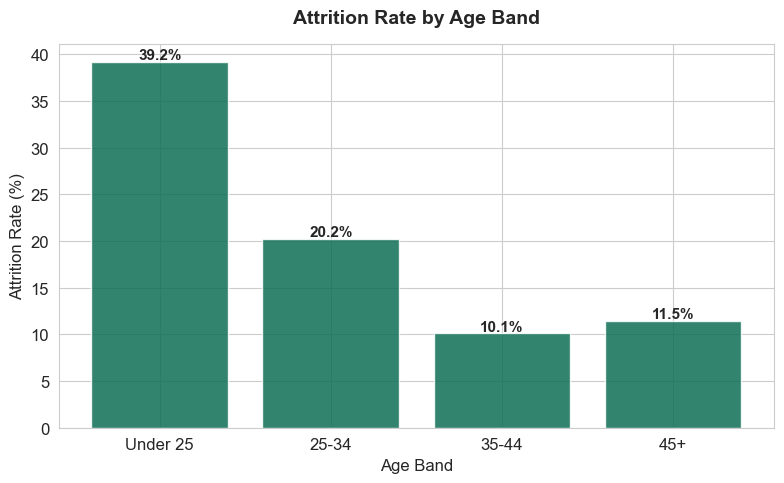

In [17]:
# ── CELL 13: EDA — Attrition by Age Band ────────────────────
age_order = ['Under 25', '25-34', '35-44', '45+']
age_attrition = df.groupby('AgeBand')['Attrition_Flag'].mean() * 100
age_attrition = age_attrition.reindex(age_order)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age_attrition.index, age_attrition.values, color='#0F6E56', alpha=0.85)
ax.set_title('Attrition Rate by Age Band', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Band')
ax.set_ylabel('Attrition Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/02_attrition_by_age.png', dpi=150)
plt.show()


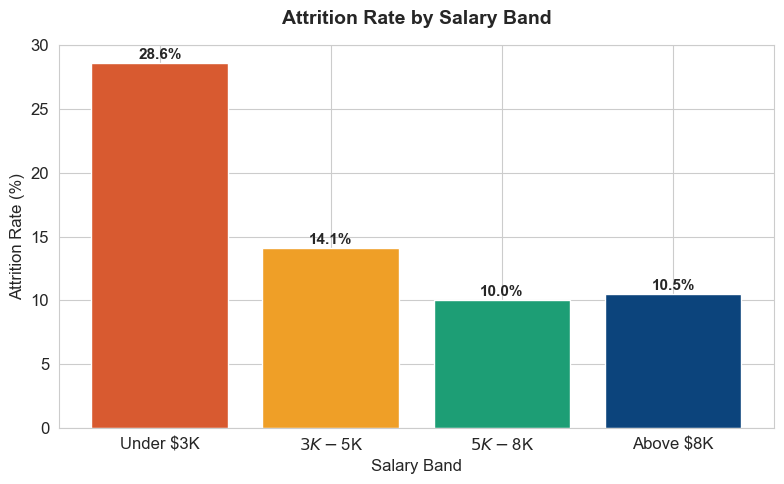

In [18]:
# ── CELL 14: EDA — Salary vs Attrition ──────────────────────
salary_order = ['Under $3K', '$3K-$5K', '$5K-$8K', 'Above $8K']
salary_attrition = df.groupby('SalaryBand')['Attrition_Flag'].mean() * 100
salary_attrition = salary_attrition.reindex(salary_order)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#D85A30', '#EF9F27', '#1D9E75', '#0C447C']
bars = ax.bar(salary_attrition.index, salary_attrition.values, color=colors)
ax.set_title('Attrition Rate by Salary Band', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Salary Band')
ax.set_ylabel('Attrition Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/03_attrition_by_salary.png', dpi=150)
plt.show()



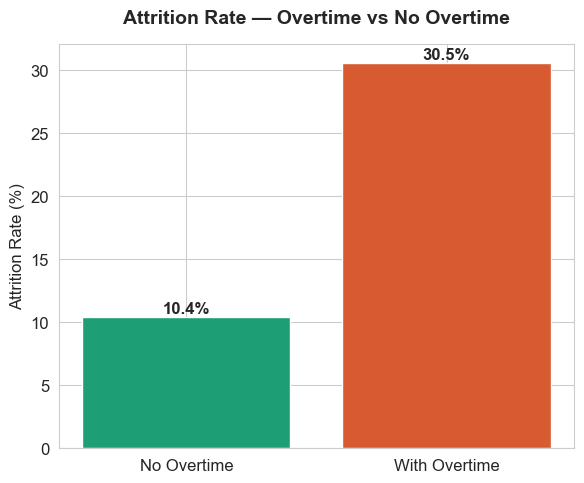

In [19]:
# ── CELL 15: EDA — Overtime vs Attrition ────────────────────
overtime_attrition = df.groupby('OverTime')['Attrition_Flag'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['No Overtime', 'With Overtime'], overtime_attrition.values,
              color=['#1D9E75', '#D85A30'])
ax.set_title('Attrition Rate — Overtime vs No Overtime', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Attrition Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/04_attrition_by_overtime.png', dpi=150)
plt.show()



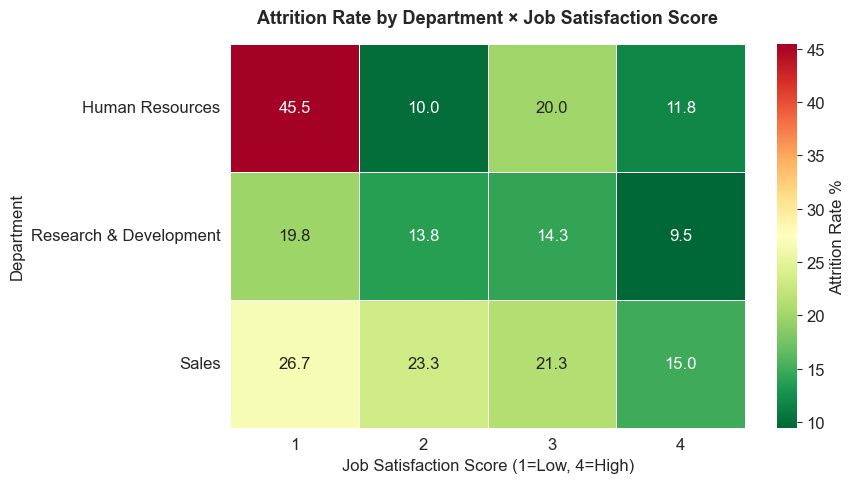

In [20]:
# ── CELL 16: EDA — Job Satisfaction Heatmap ─────────────────
pivot = df.pivot_table(
    values='Attrition_Flag',
    index='Department',
    columns='JobSatisfaction',
    aggfunc='mean'
) * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attrition Rate %'})
ax.set_title('Attrition Rate by Department × Job Satisfaction Score',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Job Satisfaction Score (1=Low, 4=High)')
ax.set_ylabel('Department')
plt.tight_layout()
plt.savefig('../screenshots/05_satisfaction_heatmap.png', dpi=150)
plt.show()

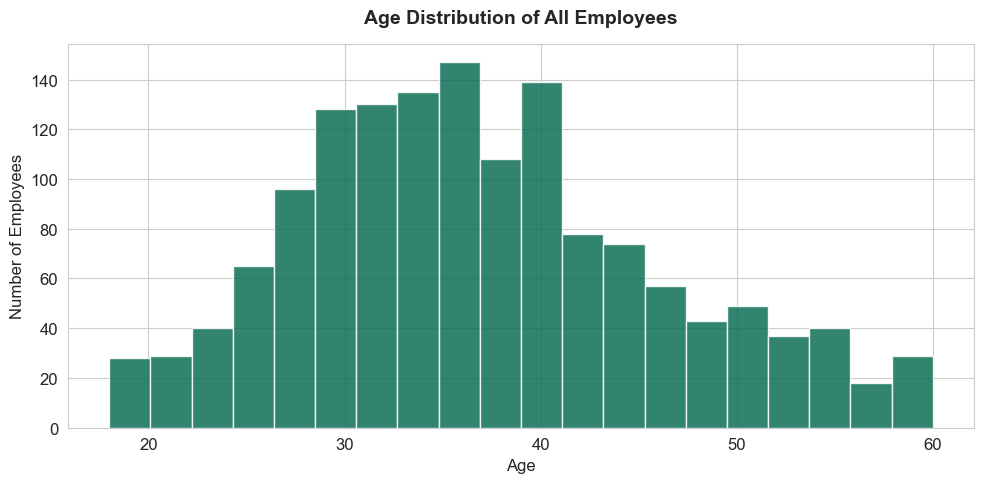

In [21]:
# ── CELL 17: EDA — Age Distribution ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Age'], bins=20, color='#0F6E56', edgecolor='white', alpha=0.85)
ax.set_title('Age Distribution of All Employees', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age')
ax.set_ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('../screenshots/06_age_distribution.png', dpi=150)
plt.show()

In [22]:
# ── CELL 18: Print key findings ─────────────────────────────
print("=" * 55)
print("  KEY FINDINGS FROM EDA")
print("=" * 55)
print(f"  Total employees          : {len(df):,}")
print(f"  Total attrition          : {df['Attrition_Flag'].sum():,}")
print(f"  Overall attrition rate   : {df['Attrition_Flag'].mean()*100:.1f}%")
print()

dept = df.groupby('Department')['Attrition_Flag'].mean()*100
print(f"  Highest attrition dept   : {dept.idxmax()} ({dept.max():.1f}%)")
print(f"  Lowest attrition dept    : {dept.idxmin()} ({dept.min():.1f}%)")
print()

ot_yes = df[df['OverTime']=='Yes']['Attrition_Flag'].mean()*100
ot_no  = df[df['OverTime']=='No']['Attrition_Flag'].mean()*100
print(f"  Attrition (Overtime=Yes) : {ot_yes:.1f}%")
print(f"  Attrition (Overtime=No)  : {ot_no:.1f}%")
print()

low_sal = df[df['SalaryBand']=='Under $3K']['Attrition_Flag'].mean()*100
hi_sal  = df[df['SalaryBand']=='Above $8K']['Attrition_Flag'].mean()*100
print(f"  Attrition (Under $3K)    : {low_sal:.1f}%")
print(f"  Attrition (Above $8K)    : {hi_sal:.1f}%")
print("=" * 55)

  KEY FINDINGS FROM EDA
  Total employees          : 1,470
  Total attrition          : 237
  Overall attrition rate   : 16.1%

  Highest attrition dept   : Sales (20.6%)
  Lowest attrition dept    : Research & Development (13.8%)

  Attrition (Overtime=Yes) : 30.5%
  Attrition (Overtime=No)  : 10.4%

  Attrition (Under $3K)    : 28.6%
  Attrition (Above $8K)    : 10.5%


In [23]:
# ── CELL 19: Export cleaned data ────────────────────────────
os.makedirs('../data/processed', exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

print(f"✅ Cleaned data saved to: {PROCESSED_PATH}")
print(f"   Final shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("New columns added:")
new_cols = ['Attrition_Flag', 'AgeBand', 'SalaryBand', 'TenureBand']
for col in new_cols:
    print(f"   + {col}")
print()
print("Next step: Run SQL files in MySQL Workbench")


✅ Cleaned data saved to: F:/Rithika/Projects/hr_analytics/data/processed/hr_cleaned.csv
   Final shape: 1470 rows × 36 columns

New columns added:
   + Attrition_Flag
   + AgeBand
   + SalaryBand
   + TenureBand

Next step: Run SQL files in MySQL Workbench
